# 1) Topology optimization with homogenization

____
|**<u>Indicative duration</u>** : 1 hour 30 minutes
|---|

There are 4 types of code cells:
- **<font color='green'>[RUN & OBSERVE]</font>** $\rightarrow$ the cell should be run directly without modification
- **<font color='orange'>[RUN & PLAY]</font>** $\rightarrow$ the cell can be run directly, but some parameters should be changed interactively
- **<font color='red'>[FILL & RUN]</font>**    $\rightarrow$ the cell should be filled before being run
- **<font color='magenta'>[FILL & PLAY]</font>** $\rightarrow$ the cell should be filled, and then some parameters should be changed interactively.

____
## A) Problem definition

|**<u>Indicative duration</u>** : 30 minutes|
|---|

The objective is to design a **<u>transformer</u>**, so to distribute iron in order to **<u>maximize the magnetic flux</u>** that is coming from the primary winding into the secondary winding.

### i) Design domain

Consider the 2D domain $\Omega$ with a boundary $\partial \Omega$, containing a primary winding $P$ with back-and-forth conductors $P_+$ and $P_-$, as well as a secondary winding with back-and-forth conductors $S_+$ and $S_-$. 
The coils are fixed and the design zone is called $\Omega_c$.

![Capture d'écran 2026-03-09 071646.png](<attachment:Capture d'écran 2026-03-09 071646.png>)

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|
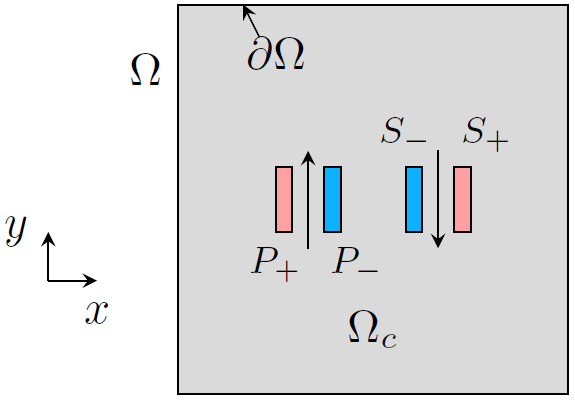

In [2]:
###############################################################################
## CODE CELL 1 : Import transformer mesh
###############################################################################

from utils.geometry import transformer
from ngsolve.webgui import Draw

mesh = transformer(maxh = 1e-2)                   #  mesh the transformer geometry
print(f"Region names : {mesh.GetMaterials()}")   # display the regions (materials) labels
print(f"Line names : {mesh.GetBoundaries()}")    # display the lines (boundaries) labels
Draw(mesh)

Region names : ('Omega_c', 'Pp', 'Pm', 'Sm', 'Sp')
Line names : ('dOmega', 'dOmega', 'dOmega', 'dOmega', 'dPp', 'dPp', 'dPp', 'dPp', 'dPm', 'dPm', 'dPm', 'dPm', 'dSm', 'dSm', 'dSm', 'dSm', 'dSp', 'dSp', 'dSp', 'dSp')


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

____
## A) Material model

|**<u>Indicative duration</u>** : 40 minutes|
|---|

With density method we use intermediate materials **<u>without physical interpretation</u>**. Homogenization theory gives an interpretation in terms of **microstructure**.

### i) Rank-1 laminate

Consider a rank-1 laminate microstructure, which is a sandwich of linear iron and air. Then, the macroscopic magnetic behavior is equivalent to an **<u>anisotropic tensor reluctivity</u>**.

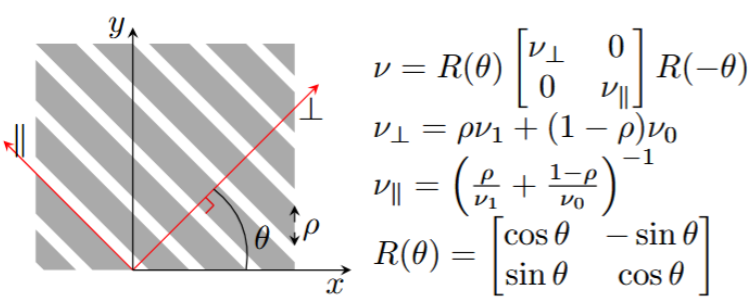

Two parameters are necessary to describe this tensor on each point of $\Omega_c$:
- The volume fraction of iron $\rho \in [0,1]$
- The fiber orientation $\theta\in[0,2\pi]$

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [3]:
from ngsolve import cos, sin, pi, CF
from ngsolve import CoefficientFunction as CF

nu0 = 1/(4e-7 * pi)
nuIron = nu0/1000

def R(theta):
    """ Rotation matrix of angle theta """
    return CF( ( (cos(theta), -sin(theta)), (sin(theta), cos(theta)) ), dims = (2,2) )

def tR(theta):
    """ Rotation matrix of angle -theta """
    return R(-theta)

def diag(c11, c22):
    """ Diagonal matrix """
    return CF( ((c11, 0), (0, c22) ), dims = (2,2))

def nu_serial(rho): 
    """ arithmetic mean of reluctivity """
    return (1-rho) * nu0 + rho * nuIron

def dnu_serial(rho): 
    return nuIron - nu0

def nu_parallel(rho) :
    """ harmonic mean """
    return 1/( (1-rho) / nu0 + rho/nuIron )

def dnu_parallel(rho) :
    return nu0 * nuIron * (nuIron - nu0) / (nuIron * (1-rho) + rho * nu0)**2

def nu_diag(rho):
    return diag(nu_serial(rho), nu_parallel(rho))
    
def nu(rho,theta):
    """ Homogenized reluctivity tensor """
    return R(theta) * nu_diag(rho) * tR(theta)
    
# Vizualize the material field
from ngsolve.webgui import Draw
def DrawMaterial(rho, theta, scene = None):
    """ plot the fibers along the parallel direction """
    mesh = rho.space.mesh
    if scene is None :
        scene = Draw(rho*CF((cos(theta+pi/2),sin(theta+pi/2))), mesh, vectors = { "grid_size":20}, 
                     settings = {"Objects" : { "Wireframe" : False } } , min=0, max=1)
        return scene
    else:
        scene.Redraw(rho*CF((cos(theta+pi/2),sin(theta+pi/2))), mesh, vectors = { "grid_size":20},
                     settings = {"Objects" : { "Wireframe" : False } }, min=0, max=1)
        
from ngsolve import GridFunction, L2
rho, theta = GridFunction(L2(mesh)), GridFunction(L2(mesh))
rho.Set(CF(0.5))
theta.Set(-pi/2)
DrawMaterial(rho,theta)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene